# Validacion de los generadores

Primer nivel de validacion del informe: cada generador contra las propiedades
teoricas de su distribucion. El segundo nivel, los invariantes del motor, va en
`simulation/metrics.py` cuando exista.

Kolmogorov-Smirnov para las continuas, chi cuadrada con colas agrupadas para las
discretas, y para el LCG ademas autocorrelacion, que es la prueba que las otras
no necesitan.

**Como leer el p-valor:** es la probabilidad de ver un desajuste asi de grande si
el generador fuera correcto. Un p-valor grande significa que no hay evidencia de
que este mal; no significa que este probado que este bien.

In [1]:
import sys, math
sys.path.insert(0, '../src')
import numpy as np, matplotlib.pyplot as plt
from scipy import stats

from bee_sim.generators import LCG, crear_fuente, poisson_knuth
from bee_sim.analysis import validation as V

AMBAR, SALVIA, TINTA = '#B87813', '#4F6B4A', '#43463C'
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
N = 20000

def linea(r):
    veredicto = 'sin evidencia de problema' if r['p_valor'] > 0.05 else 'REVISAR'
    print(f"{r['generador']:<42} {r['prueba']:>5}  est={r['estadistico']:8.4f}  "
          f"p={r['p_valor']:.4f}  {veredicto}")
    return r

resultados = []

## La fuente: el generador congruencial lineal

Un generador puede tener media 0.5 y varianza 1/12 perfectas y aun asi ser malo
si cada numero depende del anterior. Por eso aqui importa mas la autocorrelacion
que el KS.

In [2]:
r = V.validar_uniforme(LCG(seed=2026), n=N)
resultados.append(linea(r))
print(f"\n  media     {r['media']:.5f}   teorica {r['media_teorica']:.5f}")
print(f"  varianza  {r['varianza']:.5f}   teorica {r['varianza_teorica']:.5f}")
print(f"  autocorrelacion maxima (retardos 1 a 10): {r['autocorrelacion_max']:.5f}")
print('  retardos:', ' '.join(f'{a:+.4f}' for a in r['autocorrelacion']))

LCG(a=1664525, c=1013904223, m=4294967296)    KS  est=  0.0059  p=0.4887  sin evidencia de problema

  media     0.50223   teorica 0.50000
  varianza  0.08368   teorica 0.08333
  autocorrelacion maxima (retardos 1 a 10): 0.01123
  retardos: +0.0072 -0.0042 +0.0017 +0.0012 -0.0030 -0.0026 +0.0049 -0.0112 -0.0069 +0.0046


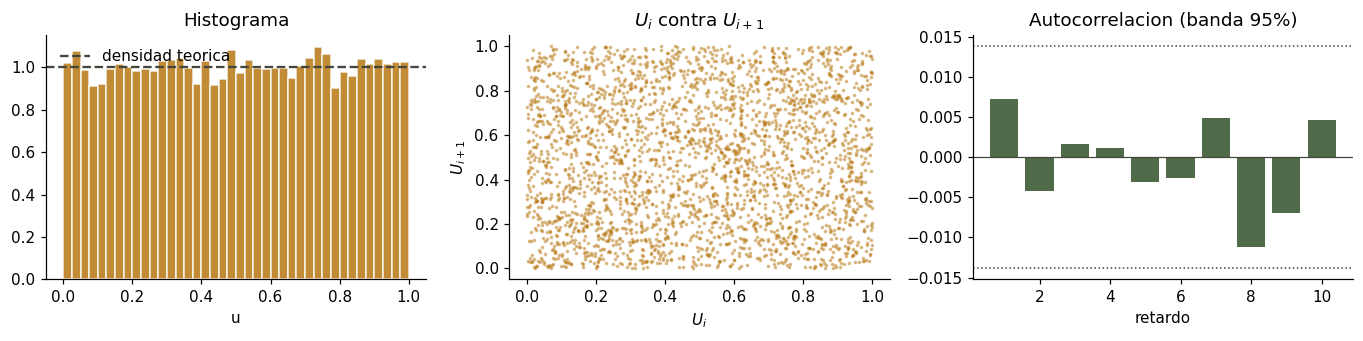

In [3]:
u = r['muestra']
fig, ax = plt.subplots(1, 3, figsize=(12.5, 3.2))

ax[0].hist(u, bins=40, density=True, color=AMBAR, edgecolor='white', alpha=.85)
ax[0].axhline(1.0, color=TINTA, ls='--', lw=1.5, label='densidad teorica')
ax[0].set_title('Histograma'); ax[0].set_xlabel('u'); ax[0].legend(frameon=False)

ax[1].scatter(u[:-1][:3000], u[1:][:3000], s=2, color=AMBAR, alpha=.4)
ax[1].set_title('$U_i$ contra $U_{i+1}$'); ax[1].set_xlabel('$U_i$'); ax[1].set_ylabel('$U_{i+1}$')

ax[2].bar(range(1, 11), r['autocorrelacion'], color=SALVIA)
ax[2].axhline(0, color=TINTA, lw=.8)
banda = 1.96/math.sqrt(N)
ax[2].axhline(banda, color=TINTA, ls=':', lw=1); ax[2].axhline(-banda, color=TINTA, ls=':', lw=1)
ax[2].set_title('Autocorrelacion (banda 95%)'); ax[2].set_xlabel('retardo')
plt.tight_layout(); plt.show()

El diagrama del medio es donde se ve la debilidad conocida de los LCG: si
aparecieran lineas o retenculas en vez de una nube pareja, la secuencia tendria
estructura. Encontrarla no seria un fracaso del proyecto, seria el resultado que
justifica haber implementado el generador propio.

## Continuas: Kolmogorov-Smirnov

Mide la distancia vertical maxima entre la acumulada de la muestra y la teorica.

In [4]:
r = LCG(seed=11)
exp_  = linea(V.validar_exponencial(2.0, r, n=N))
weib  = linea(V.validar_weibull(2.0, 1.5, r, n=N))
gam   = linea(V.validar_gamma(2.5, 1.2, r, n=N))
resultados += [exp_, weib, gam]

print('\nprueba de humo: Weibull(1, 0.5) debe comportarse como Exponencial(2)')
w1 = V.validar_weibull(1.0, 0.5, LCG(seed=11), n=N)
print(f"  media observada {w1['media']:.5f}   teorica 0.50000")

Exponencial(2)                                KS  est=  0.0090  p=0.0784  sin evidencia de problema
Weibull(2, 1.5)                               KS  est=  0.0046  p=0.7910  sin evidencia de problema
Gamma(2.5, 1.2)                               KS  est=  0.0059  p=0.4970  sin evidencia de problema

prueba de humo: Weibull(1, 0.5) debe comportarse como Exponencial(2)
  media observada 0.50671   teorica 0.50000


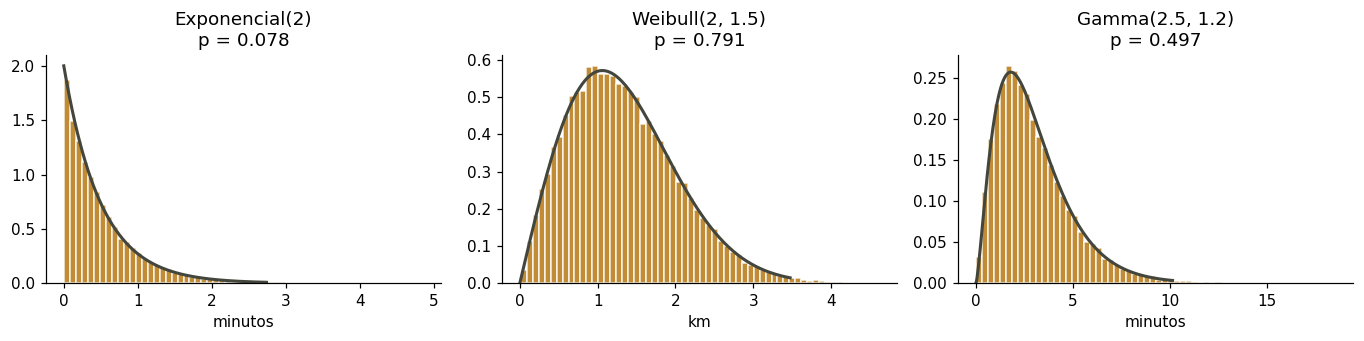

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(12.5, 3.2))
for a, res, pdf, titulo, xl in [
    (ax[0], exp_, lambda x: stats.expon.pdf(x, scale=0.5), 'Exponencial(2)', 'minutos'),
    (ax[1], weib, lambda x: stats.weibull_min.pdf(x, 2.0, 0, 1.5), 'Weibull(2, 1.5)', 'km'),
    (ax[2], gam,  lambda x: stats.gamma.pdf(x, 2.5, 0, 1.2), 'Gamma(2.5, 1.2)', 'minutos')]:
    m = res['muestra']
    a.hist(m, bins=60, density=True, color=AMBAR, edgecolor='white', alpha=.85)
    x = np.linspace(0, np.percentile(m, 99.5), 300)
    a.plot(x, pdf(x), color=TINTA, lw=2)
    a.set_title(f"{titulo}\np = {res['p_valor']:.3f}"); a.set_xlabel(xl)
plt.tight_layout(); plt.show()

## Discretas: chi cuadrada con colas agrupadas

Sin agrupar las categorias con menos de 5 casos esperados, la prueba se
desestabiliza en las colas, donde una sola observacion inflaria el estadistico.

In [6]:
r = LCG(seed=23)
poi  = linea(V.validar_poisson(8.0, r, n=N))
knu  = linea(V.validar_poisson(8.0, r, n=N, generador=poisson_knuth))
bino = linea(V.validar_binomial(10, 0.65, r, n=N))
nbin = linea(V.validar_binomial_negativa(8.0, 3.0, r, n=N))
resultados += [poi, knu, bino, nbin]

print('\nla binomial negativa debe salir SOBREDISPERSA, no Poisson:')
print(f"  varianza observada {nbin['varianza']:.3f}   teorica mu + mu^2/r = {nbin['varianza_teorica']:.3f}")
print(f"  (una Poisson con la misma media tendria varianza {nbin['media_teorica']:.3f})")

Poisson(8) via poisson_inversa              chi2  est= 13.8167  p=0.8397  sin evidencia de problema
Poisson(8) via poisson_knuth                chi2  est= 16.0525  p=0.7134  sin evidencia de problema
Binomial(10, 0.65)                          chi2  est=  9.6460  p=0.3799  sin evidencia de problema


BinNeg(mu=8, forma=3)                       chi2  est= 43.2564  p=0.1594  sin evidencia de problema

la binomial negativa debe salir SOBREDISPERSA, no Poisson:
  varianza observada 29.500   teorica mu + mu^2/r = 29.333
  (una Poisson con la misma media tendria varianza 8.000)


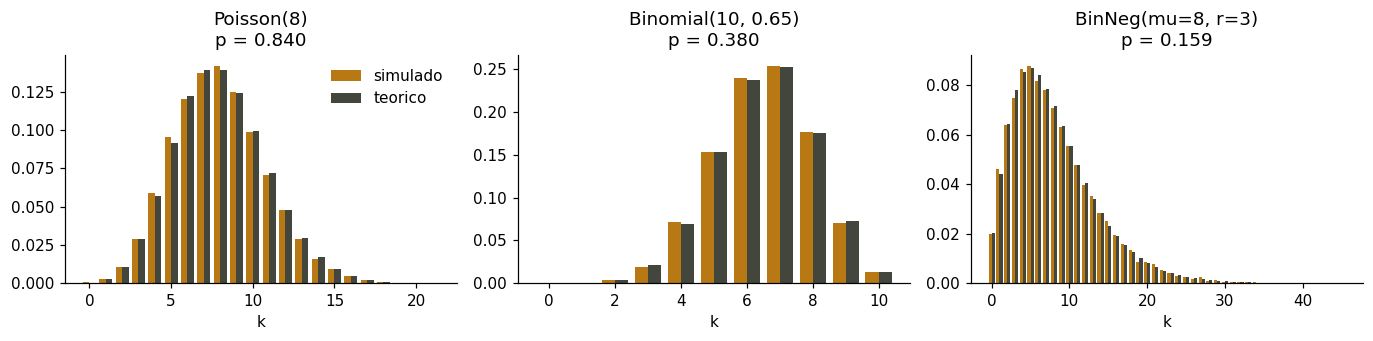

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(12.5, 3.2))
for a, res, pmf, titulo in [
    (ax[0], poi,  lambda k: stats.poisson.pmf(k, 8.0), 'Poisson(8)'),
    (ax[1], bino, lambda k: stats.binom.pmf(k, 10, 0.65), 'Binomial(10, 0.65)'),
    (ax[2], nbin, lambda k: stats.nbinom.pmf(k, 3.0, 3.0/(3.0+8.0)), 'BinNeg(mu=8, r=3)')]:
    m = res['muestra']; ks = np.arange(0, int(m.max())+1)
    obs = np.array([np.mean(m == k) for k in ks])
    a.bar(ks-0.2, obs, width=.4, color=AMBAR, label='simulado')
    a.bar(ks+0.2, pmf(ks), width=.4, color=TINTA, label='teorico')
    a.set_title(f"{titulo}\np = {res['p_valor']:.3f}"); a.set_xlabel('k')
    if a is ax[0]: a.legend(frameon=False)
plt.tight_layout(); plt.show()

## La validacion que sale gratis: adelgazamiento

Si `F ~ Poisson(mu)` y cada visita poliniza con probabilidad `p`, entonces la
marginal de flores polinizadas es exactamente `Poisson(mu*p)`.

Es la unica prueba del proyecto contra un teorico exacto que no depende de
calibrar ningun parametro, y pasa solo si el generador Poisson esta bien, el
Bernoulli esta bien, **y ademas estan bien encadenados**. Es una prueba de
integracion disfrazada de prueba estadistica.

**Ojo:** solo vale con `A_f` fijo. Una mezcla de tres Poissons no es una Poisson,
asi que corrida sobre la marginal agregada del escenario BASE la prueba falla, y
no porque el codigo este mal.

In [8]:
adel = linea(V.validar_adelgazamiento(8.0, 0.65, LCG(seed=31), n=N))
resultados.append(adel)
print(f"\n  media    {adel['media']:.4f}   teorica mu*p = {adel['media_teorica']:.4f}")
print(f"  varianza {adel['varianza']:.4f}   teorica mu*p = {adel['varianza_teorica']:.4f}")
print('  (en una Poisson la media y la varianza deben coincidir: esa es la prueba de fuego)')

Adelgazamiento: Poisson(8) filtrada con p=0.65  chi2  est= 19.1196  p=0.2084  sin evidencia de problema

  media    5.1879   teorica mu*p = 5.2000
  varianza 5.0611   teorica mu*p = 5.2000
  (en una Poisson la media y la varianza deben coincidir: esa es la prueba de fuego)


## Tabla para el informe

In [9]:
print(f"{'Generador':<44} {'n':>7} {'Prueba':>7} {'Estadistico':>12} {'p-valor':>9}")
print('-'*84)
for r in resultados:
    print(f"{r['generador']:<44} {r['n']:7d} {r['prueba']:>7} "
          f"{r['estadistico']:12.4f} {r['p_valor']:9.4f}")
print('-'*84)
malos = [r for r in resultados if r['p_valor'] <= 0.05]
print(f'{len(resultados)} generadores validados, {len(malos)} con p <= 0.05')

Generador                                          n  Prueba  Estadistico   p-valor
------------------------------------------------------------------------------------
LCG(a=1664525, c=1013904223, m=4294967296)     20000      KS       0.0059    0.4887
Exponencial(2)                                 20000      KS       0.0090    0.0784
Weibull(2, 1.5)                                20000      KS       0.0046    0.7910
Gamma(2.5, 1.2)                                20000      KS       0.0059    0.4970
Poisson(8) via poisson_inversa                 20000    chi2      13.8167    0.8397
Poisson(8) via poisson_knuth                   20000    chi2      16.0525    0.7134
Binomial(10, 0.65)                             20000    chi2       9.6460    0.3799
BinNeg(mu=8, forma=3)                          20000    chi2      43.2564    0.1594
Adelgazamiento: Poisson(8) filtrada con p=0.65   20000    chi2      19.1196    0.2084
-------------------------------------------------------------------------